In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pl.read_parquet("../../data/BTSv3/val_PS_ZTF.parquet")
df.head()

ZTFID,bts_class,objectId,jd,label,fid,diffmaglim,programid,candid,isdiffpos,field,ra,dec,magpsf,sigmapsf,chipsf,magap,sigmagap,distnr,magnr,chinr,sharpnr,sky,magdiff,fwhm,classtar,mindtoedge,seeratio,nneg,nbad,magapbig,sigmagapbig,sgmag1,srmag1,simag1,szmag1,sgscore1,…,lasttnow,peakabs,duration,rise,fade,type,vissave,vispeak30,visnow,b,A_V,Unnamed: 0,RCF_save_time,RCF_trigger_time,ra [deg],dec [deg],classification,probability,annotation origin,annotation origin key-value pair count,annotation key,annotation value,groups,Saved at,Alias,Origin,TNS,nondet_jd,nondet_diffmaglim,W1mag,W2mag,W3mag,W4mag,ps,g_reference,r_reference,i_reference
str,str,list[str],list[f64],list[i64],list[i64],list[f64],list[i64],list[i64],list[str],list[i64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[i64],list[i64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],…,f64,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,str,str,str,str,str,f64,str,str,list[f64],list[f64],f64,f64,f64,f64,list[f64],list[f64],list[f64],list[f64]
"""ZTF22aausgkx""","""SN Ia""","[""ZTF22aausgkx"", ""ZTF22aausgkx"", … ""ZTF22aausgkx""]","[2.4598e6, 2.4598e6, … 2.4609e6]","[1, 1, … 1]","[1, 2, … 2]","[19.650711, 19.741713, … 20.28364]","[1, 1, … 2]","[2026417893015015004, 2028434693015015003, … 3135439935515010003]","[""t"", ""t"", … ""f""]","[292, 292, … 1284]","[343.178339, 343.178359, … 343.178346]","[-25.637069, -25.637198, … -25.637298]","[19.415668, 18.995457, … 19.76136]","[0.167295, 0.116625, … 0.143792]","[1.29178, 1.185346, … 1.104132]","[19.509001, 18.9415, … 19.7379]","[0.3341, 0.1662, … 0.2379]","[0.764188, 0.322389, … 0.251614]","[18.714001, 17.931999, … 17.754]","[2.274, 2.747, … 3.563]","[0.123, 0.35, … 0.237]","[0.296724, -0.543859, … -0.177082]","[0.093332, -0.053956, … -0.023461]","[2.26, 2.13, … 2.34]","[0.954, 0.92, … 0.699]","[518.740723, 486.834015, … 410.658112]","[1.139443, 1.349369, … 1.094181]","[6, 3, … 2]","[0, 0, … 0]","[19.325001, 18.937401, … 19.829599]","[0.3612, 0.2106, … 0.328]","[18.879499, 18.879499, … 18.879499]","[18.299, 18.299, … 18.299]","[17.928801, 17.928801, … 17.928801]","[17.813499, 17.813499, … 17.813499]","[0.0, 0.0, … 0.0]",…,-903.51,"""-19.45""","""30.447""","""7.491""","""22.956""","""SN Ia""",1.534261,1.534244,0.0,-63.429645,0.067,5045.0,2.4598e6,1.0000e10,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,14.647,14.609,12.393,9.06,"[0.196078, 0.313726, … 0.309804]","[0.015914, 0.015573, … 0.016282]","[0.015673, 0.015864, … 0.016257]",null
"""ZTF24aaheqkp""","""SN Ia""","[""ZTF24aaheqkp"", ""ZTF24aaheqkp"", … ""ZTF24aaheqkp""]","[2.4604e6, 2.4604e6, … 2.4604e6]","[1, 1, … 1]","[2, 2, … 2]","[19.481117, 19.719336, … 20.561872]","[1, 1, … 1]","[2633495524815015015, 2633496006015015027, … 2680473274815015026]","[""t"", ""t"", … ""t""]","[828, 829, … 828]","[308.268006, 308.268048, … 308.267923]","[65.058647, 65.058665, … 65.058658]","[18.771414, 18.80196, … 19.876492]","[0.150453, 0.124622, … 0.175143]","[1.416638, 1.833492, … 1.808743]","[18.6472, 18.9401, … 19.8018]","[0.1414, 0.1565, … 0.2143]","[2.620519, 3.946732, … 2.746446]","[20.153999, 19.594999, … 20.153999]","[2.554, 0.896, … 2.554]","[0.353, 0.07, … 0.353]","[-0.934048, -0.340546, … 0.663304]","[-0.124213, 0.13814, … -0.074692]","[3.39, 2.95, … 2.2]","[0.963, 0.977, … 0.972]","[722.88739, 355.786713, … 747.679871]","[0.955701, 1.047515, … 1.067922]","[2, 3, … 6]","[0, 0, … 0]","[18.6196, 18.878901, … 19.999599]","[0.176, 0.1887, … 0.3257]","[20.895201, 20.895201, … 20.895201]","[20.131201, 20.131201, … 20.131201]","[20.113501, 20.113501, … 20.113501]","[20.132999, 20.132999, … 20.132999]","[0.001667, 0.001667, … 0.001667]",…,-293.36,"""-19.28""",""">28.558""",""">3.98""","""24.578""","""SN Ia""",2.474859,3.820628,1.210078,14.621491,1.066,6191.0,2.4604e6,2.4604e6,null,null,n

In [3]:
def get_images(id):
    row = df.filter(pl.col('ZTFID') == id)[0]

    id = row['ZTFID'].item()
    c = row['bts_class'].item()
    ps_img = np.array(row['ps'].to_list()).reshape((3, 252, 252))
    ztf_g = np.array(row['g_reference'].to_list()).reshape((63, 63)) if row['g_reference'].is_not_null().item() else None
    ztf_r = np.array(row['r_reference'].to_list()).reshape((63, 63)) if row['r_reference'].is_not_null().item() else None
    ztf_i = np.array(row['i_reference'].to_list()).reshape((63, 63)) if row['i_reference'].is_not_null().item() else None

    d = {
        'id': id,
        'class': c,
        'ps': ps_img,
        'ztf_g': ztf_g,
        'ztf_r': ztf_r,
        'ztf_i': ztf_i
    }

    return d

In [4]:
def plot_images(id):
    images = get_images(id)

    label_size = 'medium'

    id = images['id']
    class_name = images['class']

    fig, axes = plt.subplots(1, 4, figsize=(8, 5))

    axes[0].imshow(np.transpose(images['ps'], (1, 2, 0)))
    axes[0].text(0.05, 0.90, 'PS1 Image', transform=axes[0].transAxes, fontsize=label_size, ha='left', color='white', fontweight='bold')

    if images['ztf_g'] is not None:
        axes[1].imshow(images['ztf_g'], cmap='gray')
        axes[1].text(0.05, 0.90, 'ZTF g Reference', transform=axes[1].transAxes, fontsize=label_size, ha='left', color='white', fontweight='bold')

    if images['ztf_r'] is not None:
        axes[2].imshow(images['ztf_r'], cmap='gray')
        axes[2].text(0.05, 0.90, 'ZTF r Reference', transform=axes[2].transAxes, fontsize=label_size, ha='left', color='white', fontweight='bold')
    if images['ztf_i'] is not None:
        axes[3].imshow(images['ztf_i'], cmap='gray')
        axes[3].text(0.05, 0.90, 'ZTF i Reference', transform=axes[3].transAxes, fontsize=label_size, ha='left', color='white', fontweight='bold')

    # hide all ticks and labels
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xticklabels([])
        ax.set_yticklabels([])

    # Add suptitle to the left side of the figure and rotate it vertically
    fig.text(
        -0.01, 0.5,
        f'{id}\n({class_name})',
        rotation=90,
        va='center',
        ha='center',
        fontsize='large',
        fontweight='bold'
    )

    plt.tight_layout()
    plt.savefig(f"{class_name}_comparison.pdf", bbox_inches='tight')

    plt.show()

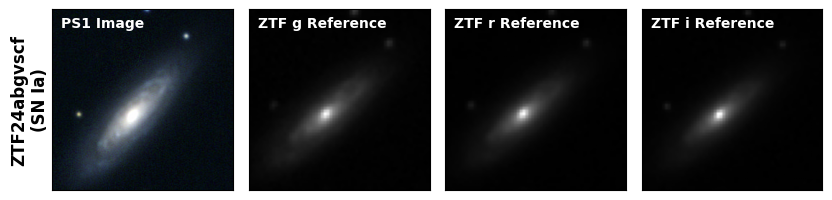

In [5]:
plot_images('ZTF24abgvscf') # ZTF24abgvscf

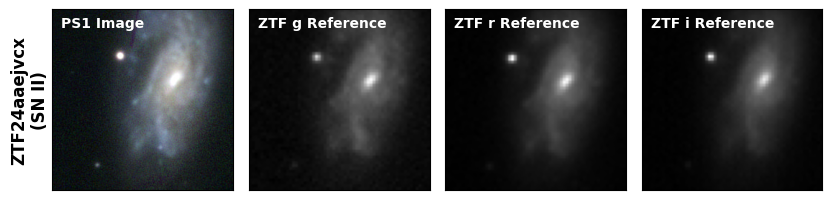

In [6]:
plot_images('ZTF24aaejvcx') # ZTF24aaejvcx

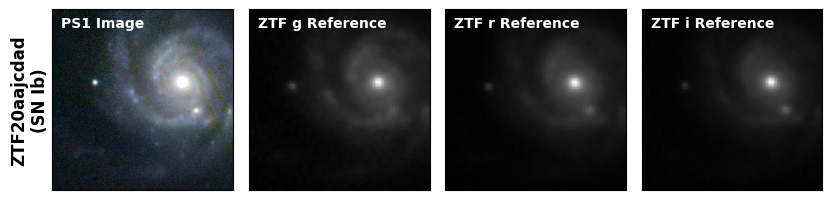

In [7]:
plot_images('ZTF20aajcdad') # ZTF20aajcdad

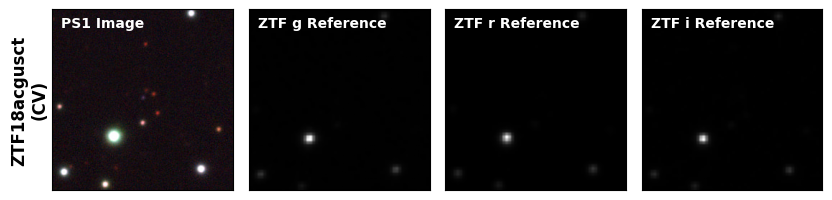

In [8]:
plot_images('ZTF18acgusct') # ZTF18acgusct

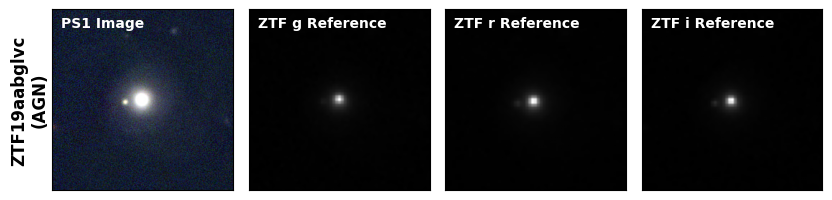

In [9]:
plot_images('ZTF19aabglvc') # ZTF19aabglvc

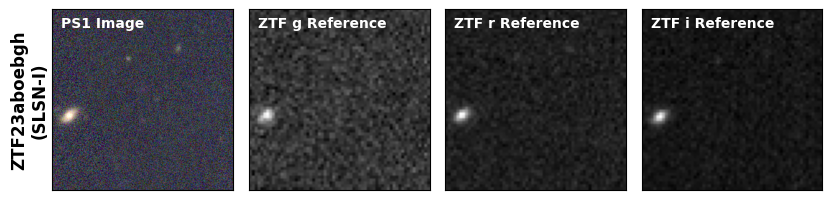

In [10]:
plot_images('ZTF23aboebgh') # ZTF23aboebgh

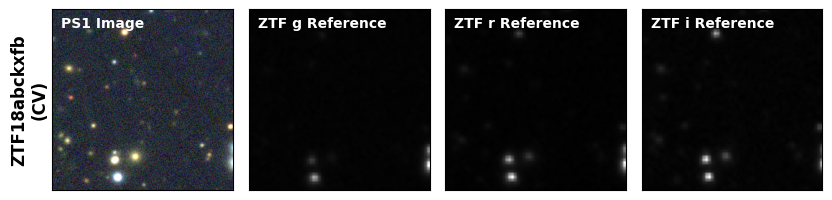

In [11]:
plot_images('ZTF18abckxfb') # ZTF18abckxfb

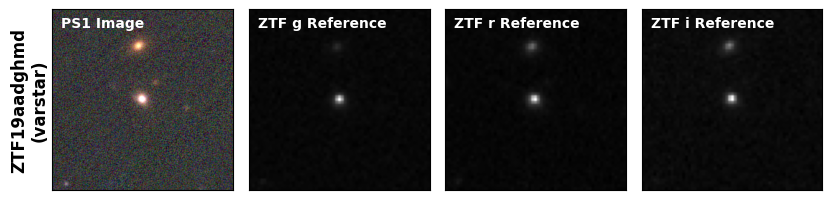

In [14]:
plot_images('ZTF19aadghmd')